# Sentiment Analysis with NLTK
Using python's [NLTK library](), we can begin to measure sentiment of a given text. This is a form of measurement that classifies text as *'Positive'*, *'Negative'* or *'Neutral'*. Powerful KPIs can be developed by mixing this analysis within an algorithm/system. In this notebook, I'm pulling data using the [news.org api]() and python's [requests]() package to query top articles from [BBC news]().

In [1]:
import os
import requests
import json
import nltk
import numpy as np
import pandas as pd
from statistics import mean
import matplotlib.pyplot as plt
from datetime import date, timedelta
from nltk.tokenize import sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

In [2]:
def get_headlines():
    # BBC news, why not
    query_params = {
      "source": "bbc-news",
      "sortBy": "top",
      "apiKey": "4dbc17e007ab436fb66416009dfb59a8"
    }
    
    main_url = " https://newsapi.org/v1/articles"
 
    # fetching data in json format
    res = requests.get(main_url, params=query_params)
    open_bbc_page = res.json()

    # getting all articles in a string article
    article = open_bbc_page["articles"]
    
    # custom data structure defines our results
    results = {
        'Titles': [], 
        'Descriptions': []
    }
    
    # add the title
    for ar in article:
        author = ar["author"]
        title = ar["title"]
        description = ar["description"]
        publishedAt = ar["publishedAt"]
        results['Titles'].append(title)
        results['Descriptions'].append(description)
    
    return results

In [3]:
bbc_news_repo = get_headlines()

## Measure Sentiment
NLTK's pre-trained sentiment intensity analyzer can be fed a string of text and will return back a 'positive', 'negative', 'neutral', and 'compound' score. The more complicated the text, the more important feature selection and customization becomes for mainting accuracy of a classifier. For the initial scoring of our BBC articles, we will look at the **mean compound sentiment** detected from all of the sentences in a given article.

For additional considerations and measurement, I'll keep three data structures to cache interesting data: *article scores, daily stats and daily scores*. 

* Article scores will store a count of articles that land in each classification (positive, negative, neutral). 
* The daily stats dictionary will store all of the calculated scores in lists keyed back to their classification
* The daily scores dictionary will store the mean of all articles for the day keyed back to it's classification

In [4]:
sia = SentimentIntensityAnalyzer()

In [5]:
def filter_compound(sentence):
    return sia.polarity_scores(sentence)["compound"]

In [6]:
article_scores = {"Positive": 0, "Negative": 0, "Neutral": 0}
daily_stats = {"Positive": [], "Negative": [], "Neutral": []}
daily_scores = {"Positive": [], "Negative": [], "Neutral": []}

In [7]:
titles = bbc_news_repo['Titles']
descriptions = bbc_news_repo['Descriptions']

In [8]:
# store averages for daily metric
indv_scores = []

# create a custom score for each article, collect daily statistics in a file
for i in range(len(titles)):
    # score with nltk
    title_sentiment = sia.polarity_scores(titles[i])
    description_sentiment = sia.polarity_scores(descriptions[i])
    article_sentiment = (title_sentiment["compound"] + description_sentiment["compound"]) / 2
    indv_scores.append(article_sentiment)
    
    if article_sentiment > 0:
        article_scores['Positive'] += 1
        daily_stats['Positive'].append(article_sentiment)
    
    elif article_sentiment < 0:
        article_scores['Negative'] += 1
        daily_stats['Negative'].append(article_sentiment)
    
    else:
        article_scores['Neutral'] += 1
        daily_stats['Neutral'].append(article_sentiment)


if mean(indv_scores) > 0:
    daily_scores['Positive'].append(mean(indv_scores))

elif mean(indv_scores) < 0:
    daily_scores['Negative'].append(mean(indv_scores))

else:
    daily_scores['Neutral'].append(mean(indv_scores))

In [9]:
article_scores

{'Positive': 2, 'Negative': 5, 'Neutral': 3}

## Plot Results
Here we will look at our article scores and make a simple pie chart to show the weight of each category for our given day. Consider that this is our simple, pre-trained model. This is a cursory view of the data. 

In [10]:
# explode the dominant classification for the batch
max_value_index = np.array(list(article_scores.values())).argmax(axis=0)
explode = np.zeros(len(article_scores.keys()))
explode[max_value_index] = 0.15

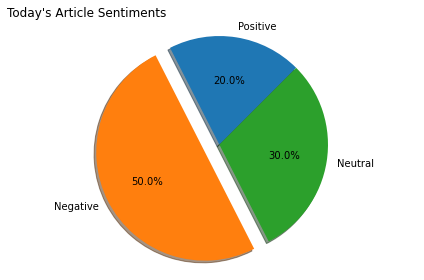

In [11]:
# pie chart
labels = article_scores.keys()
percentages = article_scores.values()

fig1, ax1 = plt.subplots()
ax1.pie(percentages, labels=labels, autopct='%1.1f%%', explode=explode, shadow=True, startangle=45)

ax1.axis('equal')

plt.title("Today's Article Sentiments", loc='left')
plt.tight_layout()

## Rolling Statistics
Now that sentiment can be analyzed and measured, we want to begin tracking data over time. We can start to come up with measures to evaluate our findings and improve our accuracy through feature selection. Through testing and benchmarking, we might be able to draw out examples that show the algorithm is underperforming, incorrectly classifying articles, etc.. We'll need good features to overcome any challenges faced.

*Storing the statistics as JSON files enable easy access for other developers that want to work with the dataset or measure it using different methods*

In [12]:
today = date.today()
today.strftime("%m%d%y")

with open('daily_sentiments/all_stats/pre-trained-{}.json'.format(today), 'w') as outfile:
    json.dump(daily_stats, outfile)

with open('daily_sentiments/mean_scores/pre-trained-{}.json'.format(today), 'w') as outfile:
    json.dump(daily_scores, outfile)

## Feature Engineering & Classification

What do we want to measure? What can we measure? How should we implement it? 

In the above example, I saved the daily statistics so that we can look at a time-series of sentiment over different windows. We might consider integrating some of the things shown here into different visualizations/systems that make the data consumable.

A simple analysis and some testing sessions would likely reveal that this pre-trained model is not always accurately classifying the text. To improve results we can analyze our datasets and implement useful features that increase accuracy.

In [13]:
stopwords = nltk.corpus.stopwords.words("english")

In [14]:
all_words = ''.join(description for description in descriptions).split()

In [15]:
# remove stopwords and any typical person names
unwanted = nltk.corpus.stopwords.words("english")
unwanted.extend([w.lower() for w in nltk.corpus.names.words()])

# tag the part of speech and ignore singular nouns
def skip_unwanted(pos_tuple):
    word, tag = pos_tuple
    if not word.isalpha() or word in unwanted:
        return False
    if tag.startswith("NN"):
        return False
    return True

# split into lists of positive/negative/neutral words for further evaluation
positive_words = [word for word, tag in filter(
    skip_unwanted,
    nltk.pos_tag([w for w in all_words if sia.polarity_scores(w)['compound'] > 0])
)]

negative_words = [word for word, tag in filter(
    skip_unwanted,
    nltk.pos_tag([w for w in all_words if sia.polarity_scores(w)['compound'] < 0])
)]

### Remove Conflicting Words

Now that we've scored the words within our dataset, lets tell the model to ignore words that received conflicting scores. With the articles pulled via the free news api, this will return limited results, but is something that could happen frequently in larger data sets.

In [16]:
# convert lists to frequency distributions
positive_fd = nltk.FreqDist(positive_words)
negative_fd = nltk.FreqDist(negative_words)

# delete words that appear in multiple frequency distributions
common_set = set(positive_fd).intersection(negative_fd)
for word in common_set:
    del positive_fd[word]
    del negative_fd[word]

# tag the most common words in each fd
top_100_positive = {word for word, count in positive_fd.most_common(100)}
top_100_negative = {word for word, count in negative_fd.most_common(100)}

### Feature Selection

In [17]:
def extract_features(text):
    features = {}
    compound_scores = []
    positive_scores = []
    wordcount = 0
    
    for sentence in nltk.sent_tokenize(text):
        for word in nltk.word_tokenize(sentence):
            if word.lower() in top_100_positive:
                wordcount += 1
        compound_scores.append(sia.polarity_scores(sentence)["compound"])
        positive_scores.append(sia.polarity_scores(sentence)["pos"])
    
    # adding 1 to the final compound score to - ensures we always have positive numbers
    # some classifiers do not work with negatives
    features["mean_compound"] = mean(compound_scores) + 1
    features["mean_positive"] = mean(positive_scores)
    features["wordcount"] = wordcount
    
    return features

In [18]:
features = [
    (extract_features(article), "pos")
    for article in descriptions
]

features.extend([
    (extract_features(article), "neg")
    for article in descriptions
])

### Model Training

![](https://i.makeagif.com/media/7-04-2021/Lrct5U.gif)

In [19]:
from random import shuffle

train_count = len(features)//4
shuffle(features)
classifier = nltk.NaiveBayesClassifier.train(features[:train_count])
classifier.show_most_informative_features(10)

Most Informative Features
               wordcount = 0                 neg : pos    =      1.5 : 1.0


In [20]:
nltk.classify.accuracy(classifier, features[train_count:])

0.3333333333333333

### Model Testing

Give the classifier examples and manually test the output. When things are incorrect, why are they incorrect? Can we train the classifier to make sure that they are correct next time?

In [21]:
first_article = bbc_news_repo['Descriptions'][0]

In [22]:
# test by classifying the first piece of text
print(classifier.classify(extract_features(first_article)))

neg


In [23]:
# show the features used inside of the model
feature_set = extract_features(first_article)
print(feature_set)

{'mean_compound': 1.1901, 'mean_positive': 0.104, 'wordcount': 0}


### Scikit-Learn Classifier Comparison
Scikit-Learn comes with a couple of different *out-of-the-box* classifiers that can help a model improve it's classification accuracy. The selection of classifiers can all be run at the same time. From the models, we are able to save the accuracy and select the top performer for the next classification task. Read more about this [here]().

In [24]:
from sklearn.naive_bayes import (
    BernoulliNB,
    ComplementNB,
    MultinomialNB,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [25]:
classifiers = {
    "BernoulliNB": BernoulliNB(),
    "ComplementNB": ComplementNB(),
    "MultinomialNB": MultinomialNB(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier(),
    "LogisticRegression": LogisticRegression(),
    "MLPClassifier": MLPClassifier(max_iter=1000),
    "AdaBoostClassifier": AdaBoostClassifier(),
}

In [26]:
# need to select a few features to continue training the models
train_count = len(features)//4
shuffle(features)
for name, sklearn_classifier in classifiers.items():
    classifier = nltk.classify.SklearnClassifier(sklearn_classifier)
    classifier.train(features[:train_count])
    accuracy = nltk.classify.accuracy(classifier, features[train_count:])
    print(F"{accuracy: .2%} - {name}")

 46.67% - BernoulliNB
 46.67% - ComplementNB
 46.67% - MultinomialNB
 46.67% - KNeighborsClassifier
 33.33% - DecisionTreeClassifier
 33.33% - RandomForestClassifier
 46.67% - LogisticRegression
 40.00% - MLPClassifier
 33.33% - AdaBoostClassifier


## Further Analysis / Feature Exploration

NLTK has a built-in object called a *frequency distribution*. This helps provide a few built-in functions for analyzing features of a given text. Again - consider the context behind the datasets being analyzed. 

In [27]:
fd = nltk.FreqDist([w.lower() for w in all_words if w.isalpha() and w not in stopwords])
fd.most_common(3)

[('members', 2), ('says', 2), ('comes', 2)]

In [28]:
fd.tabulate(10)

    members        says       comes          eu       agree voluntarily      reduce         gas         use        seek 
          2           2           2           1           1           1           1           1           1           1 


In [29]:
fd['members']

2

### Extracting Concordances & Collocations

A concordance is a collection of word locations along with their context. NLTK provides a .concordance() function for instances of *nltk.Text* objects. These can be built with a list of words and then the concordance allows you to quickly find:

* How many times a word appears
* Where each occurrence appears
* What words surround each occurrence

In [30]:
# create instance and display limit of matches
text = nltk.Text(all_words)
text.concordance('members', lines=5)

Displaying 2 of 2 matches:
EU members agree to voluntarily reduce gas use
ily reduce gas use by 15%, but some members can seek exemptions.The Chinese mil


**Concordance_lists** allow us to cache information in an easy to access list of ConcordanceLine objects. These contain information about where each word occurs and is sorted in order of appearance. Using the nltk.Text object also has a built-in method for creating a frequency distribution called .vocab().

In [31]:
concordance_list = text.concordance_list('coronavirus', lines=2)
for entry in concordance_list:
    print(entry.line)

NLTK is also able to quickly find collocations with simple function calls. Collocations are series of words that frequently appear together in a given text. Collocations are made up of two or more words. NLTK provides classes to handle several types of collocations:

* Bigrams: Frequent two-word combinations
* Trigrams: Frequent three-word combinations
* Quadgrams: Frequent four-word combinations

In [32]:
finder = nltk.collocations.TrigramCollocationFinder.from_words(all_words)

In [33]:
finder.ngram_fd.most_common(5)

[(('EU', 'members', 'agree'), 1),
 (('members', 'agree', 'to'), 1),
 (('agree', 'to', 'voluntarily'), 1),
 (('to', 'voluntarily', 'reduce'), 1),
 (('voluntarily', 'reduce', 'gas'), 1)]

In [34]:
finder.ngram_fd.tabulate(3)

    ('EU', 'members', 'agree')     ('members', 'agree', 'to') ('agree', 'to', 'voluntarily') 
                             1                              1                              1 


In [35]:
positive_bigram_finder = nltk.collocations.BigramCollocationFinder.from_words([
    w for w in [w for w in all_words if sia.polarity_scores(w)['compound'] > 0]
    if w.isalpha() and w not in unwanted
])

negative_bigram_finder = nltk.collocations.BigramCollocationFinder.from_words([
    w for w in [w for w in all_words if sia.polarity_scores(w)['compound'] < 0]
    if w.isalpha() and w not in unwanted
])

In [36]:
bigram_measures = nltk.collocations.BigramAssocMeasures()
print("Positive Bigrams:", positive_bigram_finder.nbest(bigram_measures.pmi, 10), '\n')
print("Negative Bigrams:", negative_bigram_finder.nbest(bigram_measures.pmi, 10))

Positive Bigrams: [('agree', 'hailed'), ('hailed', 'growing')] 

Negative Bigrams: [('abuse', 'fight'), ('collapses', 'resigns'), ('criticising', 'abuse'), ('resigns', 'criticising')]


# Conclusions

Questions matter. The data set matters. What we want to know will dictate the inputs to our models and help us gauge what we're training for. Make sure to save your models and regularly check your *priors* to ensure your analysis makes sense and is not based off of any kind of wild assumption.